# 🏥 Multivariate Linear Regression Practice Assignment
# Medical Insurance Price Prediction

---

**Course:** Machine Learning — Regression  
**Dataset:** Medical Insurance Price Prediction  
**Target Variable:** `charges` (Insurance Cost in USD)  

---

## 📌 Objective

In this assignment, you will:
- Predict medical insurance **charges** using multiple independent variables
- Understand how **Multivariate Linear Regression** works on a real-world dataset
- Practice **data preprocessing**, **feature encoding**, **model training**, **prediction**, and **evaluation**
- Experiment with different feature combinations and compare model performance

---

## 📐 Regression Formula

The general idea behind this assignment:

$$\text{Charges} = (m_1 \times \text{age}) + (m_2 \times \text{bmi}) + (m_3 \times \text{children}) + (m_4 \times \text{smoker}) + (m_5 \times \text{sex}) + (m_6 \times \text{region}) + b$$

Where $m_1, m_2, ...$ are **coefficients** and $b$ is the **intercept** learned by the model.

> ⚠️ Note: `sex`, `smoker`, and `region` are **categorical variables** and must be **encoded** into numbers before they can be used in a linear regression model.

---

## 📦 Step 1 — Import Required Libraries

In [1]:
# ── Core Libraries ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Scikit-learn ─────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ── Display Settings ─────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## 📂 Step 2 — Load the Dataset

In [2]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Path to your dataset in Google Drive
file_path = "/content/drive/MyDrive/Medical_insurance.csv"

# Load the dataset
df = pd.read_csv(file_path)

# Display dataset information
print("✅ Dataset loaded successfully!")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

# Preview first 5 rows
df.head()

Mounted at /content/drive
✅ Dataset loaded successfully!
Rows    : 2772
Columns : 7


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.92
1,18,male,33.77,1,no,southeast,1725.55
2,28,male,33.00,3,no,southeast,4449.46
3,33,male,22.70,0,no,northwest,21984.47
4,32,male,28.88,0,no,northwest,3866.86


---
## 🔍 Step 3 — Dataset Understanding

Before building any model, we must first understand the dataset. This includes:
- What columns (features) are available?
- What data types do they have?
- What does the target variable look like?
- Are there any missing values?

In [3]:
# ── 3.1  First 5 rows ────────────────────────────────────────────
print("=" * 55)
print("  FIRST 5 ROWS OF THE DATASET")
print("=" * 55)
df.head()

  FIRST 5 ROWS OF THE DATASET


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.92
1,18,male,33.77,1,no,southeast,1725.55
2,28,male,33.00,3,no,southeast,4449.46
3,33,male,22.70,0,no,northwest,21984.47
4,32,male,28.88,0,no,northwest,3866.86


In [4]:
# ── 3.2  Shape, Column Names, Data Types ─────────────────────────
print("\n📐 Shape:", df.shape)
print("\n📋 Column Names:")
print(df.columns.tolist())
print("\n🔢 Data Types:")
print(df.dtypes)


📐 Shape: (2772, 7)

📋 Column Names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

🔢 Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [5]:
# ── 3.3  Summary Statistics ───────────────────────────────────────
print("=" * 55)
print("  SUMMARY STATISTICS (Numeric Features)")
print("=" * 55)
df.describe()

  SUMMARY STATISTICS (Numeric Features)


,age,bmi,children,charges
count,2772.00,2772.00,2772.00,2772.00
mean,39.11,30.70,1.10,13261.37
std,14.08,6.13,1.21,12151.77
min,18.00,15.96,0.00,1121.87
25%,26.00,26.22,0.00,4687.80
50%,39.00,30.45,1.00,9333.01
75%,51.00,34.77,2.00,16577.78
max,64.00,53.13,5.00,63770.43


In [6]:
# ── 3.4  Missing Values Check ─────────────────────────────────────
print("=" * 55)
print("  MISSING VALUES PER COLUMN")
print("=" * 55)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

if missing.sum() == 0:
    print("\n✅ No missing values found — dataset is clean!")
else:
    print("\n⚠️  Missing values detected — handle them in preprocessing.")

  MISSING VALUES PER COLUMN
          Missing Count  Missing %
age                   0       0.00
sex                   0       0.00
bmi                   0       0.00
children              0       0.00
smoker                0       0.00
region                0       0.00
charges               0       0.00

✅ No missing values found — dataset is clean!


In [7]:
# ── 3.5  Unique Values in Categorical Columns ─────────────────────
categorical_cols = ['sex', 'smoker', 'region']
print("=" * 55)
print("  UNIQUE VALUES IN CATEGORICAL COLUMNS")
print("=" * 55)
for col in categorical_cols:
    print(f"\n{col}: {df[col].unique().tolist()}  (Count: {df[col].nunique()})")

  UNIQUE VALUES IN CATEGORICAL COLUMNS

sex: ['female', 'male']  (Count: 2)

smoker: ['yes', 'no']  (Count: 2)

region: ['southwest', 'southeast', 'northwest', 'northeast']  (Count: 4)


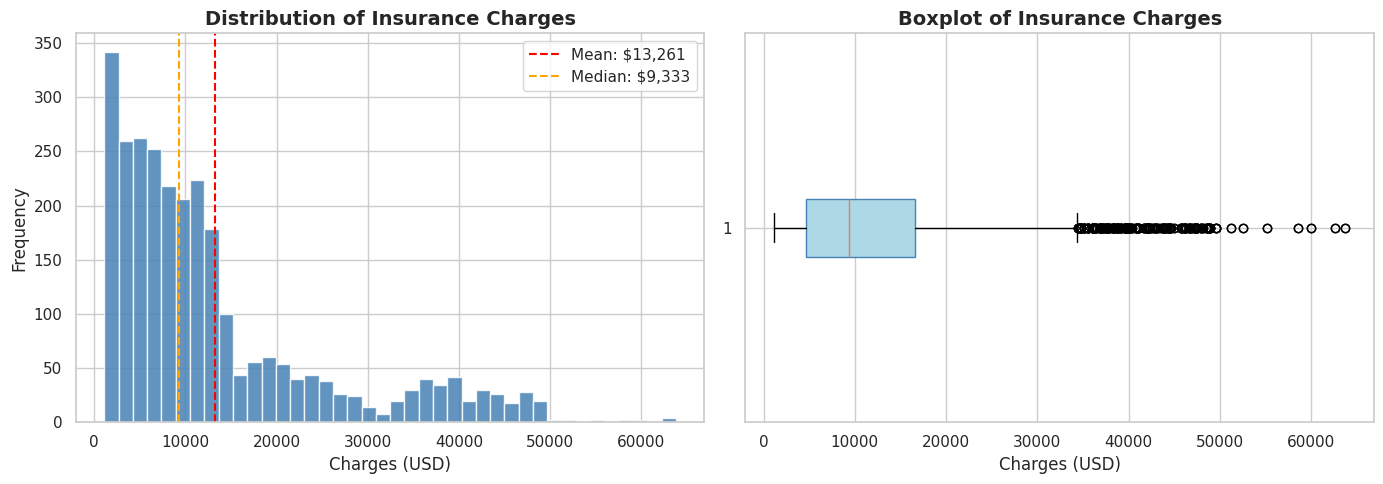


📊 Target Variable Statistics:
   Min    : $1,121.87
   Max    : $63,770.43
   Mean   : $13,261.37
   Median : $9,333.01
   Std Dev: $12,151.77


In [8]:
# ── 3.6  Target Variable Distribution ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['charges'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Insurance Charges', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Charges (USD)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['charges'].mean(), color='red', linestyle='--', label=f"Mean: ${df['charges'].mean():,.0f}")
axes[0].axvline(df['charges'].median(), color='orange', linestyle='--', label=f"Median: ${df['charges'].median():,.0f}")
axes[0].legend()

# Boxplot
axes[1].boxplot(df['charges'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'))
axes[1].set_title('Boxplot of Insurance Charges', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Charges (USD)')

plt.tight_layout()
plt.show()

print(f"\n📊 Target Variable Statistics:")
print(f"   Min    : ${df['charges'].min():,.2f}")
print(f"   Max    : ${df['charges'].max():,.2f}")
print(f"   Mean   : ${df['charges'].mean():,.2f}")
print(f"   Median : ${df['charges'].median():,.2f}")
print(f"   Std Dev: ${df['charges'].std():,.2f}")

---
## 🔧 Step 4 — Data Preprocessing

Linear regression works only with **numeric data**. We need to:
1. Confirm no null values exist (or handle them)
2. Encode categorical variables (`sex`, `smoker`, `region`) into numbers

**Why encoding is necessary:**  
Linear regression computes weighted sums (e.g., $m \times \text{feature}$). You cannot multiply a weight by the word "male" or "yes" — they must be numbers first.

In [9]:
# ── 4.1  Make a Working Copy ──────────────────────────────────────
df_encoded = df.copy()
print("✅ Working copy created. Original dataset is preserved.")

✅ Working copy created. Original dataset is preserved.


In [10]:
# ── 4.2  Encode Binary Categorical Variables ───────────────────────
# sex   : female → 0, male → 1
# smoker: no    → 0, yes  → 1

le = LabelEncoder()

df_encoded['sex_encoded']    = le.fit_transform(df_encoded['sex'])     # female=0, male=1
df_encoded['smoker_encoded'] = le.fit_transform(df_encoded['smoker'])  # no=0, yes=1

print("📌 Encoding Results:")
print("   sex    :", dict(zip(df['sex'].unique(),
                               df_encoded['sex_encoded'][df['sex'].isin(df['sex'].unique())].unique())))
print("   smoker :", dict(zip(df['smoker'].unique(),
                               df_encoded['smoker_encoded'][df['smoker'].isin(df['smoker'].unique())].unique())))
print("\n✅ Binary columns encoded!")

📌 Encoding Results:
   sex    : {'female': np.int64(0), 'male': np.int64(1)}
   smoker : {'yes': np.int64(1), 'no': np.int64(0)}

✅ Binary columns encoded!


In [ ]:
# ── 4.3  Encode Region (One-Hot Encoding — 4 categories) ──────────
# One-Hot Encoding creates a separate 0/1 column for each category.
# We drop the first column (drop_first=True) to avoid multicollinearity.

region_dummies = pd.get_dummies(df_encoded['region'], prefix='region', drop_first=True, dtype=int)
df_encoded = pd.concat([df_encoded, region_dummies], axis=1)

print("📌 Region one-hot encoding columns created:")
print("  ", region_dummies.columns.tolist())
print("\nSample encoded data:")
df_encoded[['region', 'region_northwest', 'region_southeast', 'region_southwest']].head(8)

In [ ]:
# ── 4.4  Final Encoded Dataset Preview ───────────────────────────
print("=" * 55)
print("  FULLY ENCODED DATASET (first 5 rows)")
print("=" * 55)
df_encoded.head()

---
## 📊 Step 5 — Exploratory Data Analysis (EDA)

Before training, let's visualize relationships between features and `charges` to build intuition.

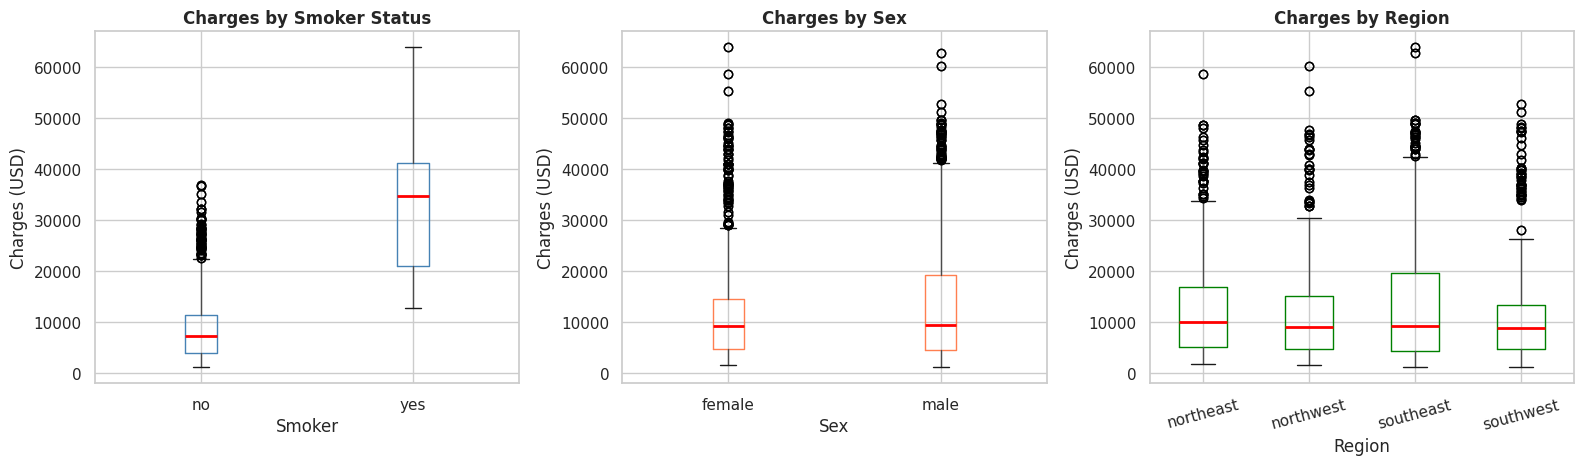

In [11]:
# ── 5.1  Charges by Smoker Status ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Smoker vs Charges
df.boxplot(column='charges', by='smoker', ax=axes[0],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Charges by Smoker Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Smoker')
axes[0].set_ylabel('Charges (USD)')

# Sex vs Charges
df.boxplot(column='charges', by='sex', ax=axes[1],
           boxprops=dict(color='coral'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Charges by Sex', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Charges (USD)')

# Region vs Charges
df.boxplot(column='charges', by='region', ax=axes[2],
           boxprops=dict(color='green'),
           medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Charges by Region', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Region')
axes[2].set_ylabel('Charges (USD)')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('')
plt.tight_layout()
plt.show()

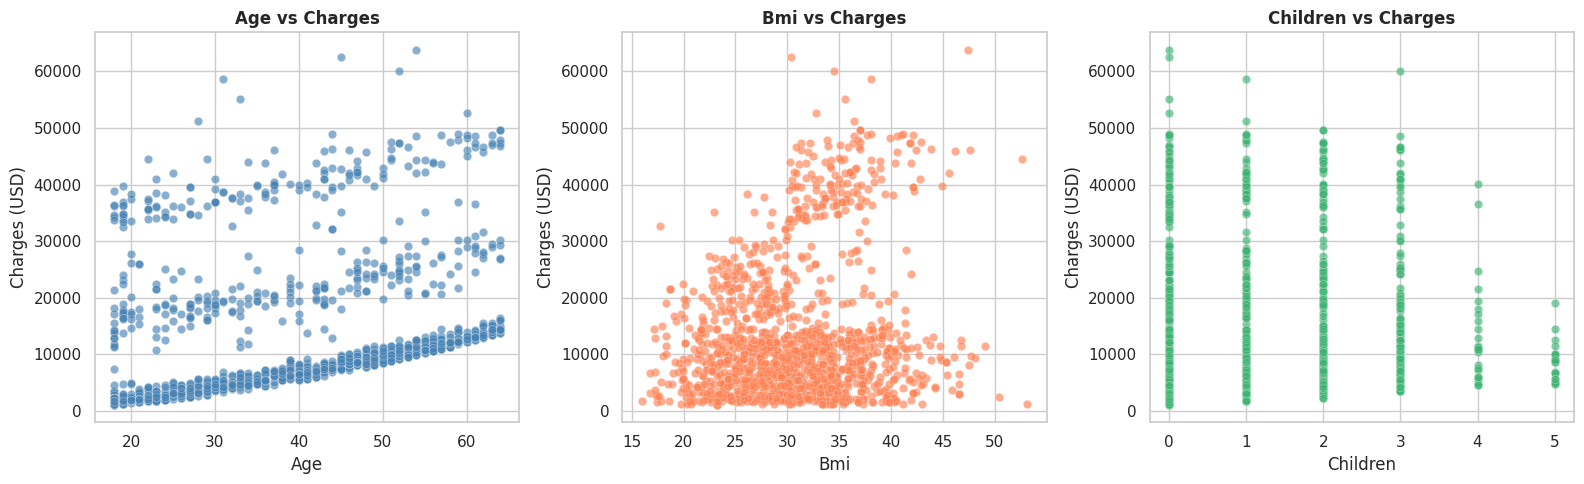

In [12]:
# ── 5.2  Scatter Plots: Numeric Features vs Charges ───────────────
numeric_features = ['age', 'bmi', 'children']
colors = ['steelblue', 'coral', 'mediumseagreen']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (feat, color) in enumerate(zip(numeric_features, colors)):
    axes[i].scatter(df[feat], df['charges'], alpha=0.4, color=color, edgecolors='white', linewidth=0.3)
    axes[i].set_title(f'{feat.capitalize()} vs Charges', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feat.capitalize())
    axes[i].set_ylabel('Charges (USD)')

plt.tight_layout()
plt.show()

Using columns: ['age', 'bmi', 'children', 'sex_encoded', 'smoker_encoded', 'charges']


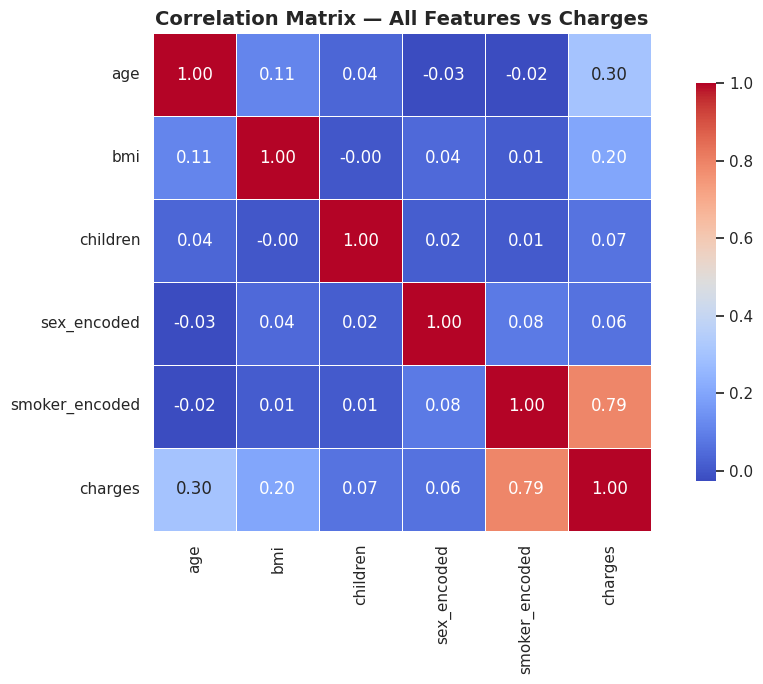


📌 Correlation with 'charges' (sorted):
smoker_encoded   0.79
age              0.30
bmi              0.20
children         0.07
sex_encoded      0.06
Name: charges, dtype: float64


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Columns you want to include
desired_cols = [
    'age', 'bmi', 'children',
    'sex_encoded', 'smoker_encoded',
    'region_northwest', 'region_southeast',
    'region_southwest', 'charges'
]

# Keep only columns that exist in df_encoded
numeric_cols = [col for col in desired_cols if col in df_encoded.columns]

print("Using columns:", numeric_cols)

# Correlation matrix
corr_matrix = df_encoded[numeric_cols].corr()

# Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Matrix — All Features vs Charges',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation with charges
print("\n📌 Correlation with 'charges' (sorted):")
print(corr_matrix['charges'].sort_values(ascending=False).drop('charges'))

---
## ✂️ Step 6 — Feature Selection & Train-Test Split

We define:
- **X** = Independent variables (features)
- **y** = Dependent variable (target = `charges`)

**Why split data?**  
If we train and test on the same data, the model might simply "memorize" the answers. A separate test set gives an honest evaluation of how the model will perform on **unseen data** in the real world.  
A standard **80/20 split** is used: 80% for training, 20% for testing.

In [18]:
# Expected features
features_full = [
    'age',
    'bmi',
    'children',
    'sex_encoded',
    'smoker_encoded',
    'region_northwest',
    'region_southeast',
    'region_southwest'
]

# Keep only columns that exist
features_full = [col for col in features_full if col in df_encoded.columns]

X = df_encoded[features_full]
y = df_encoded['charges']

print("✅ Feature matrix X:")
print(f"   Shape   : {X.shape}")
print(f"   Features: {features_full}")

print("\n✅ Target vector y:")
print(f"   Shape   : {y.shape}")
print("   Column  : charges")

✅ Feature matrix X:
   Shape   : (2772, 5)
   Features: ['age', 'bmi', 'children', 'sex_encoded', 'smoker_encoded']

✅ Target vector y:
   Shape   : (2772,)
   Column  : charges


In [19]:
# ── 6.2  Train-Test Split ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("=" * 45)
print("  TRAIN-TEST SPLIT SUMMARY")
print("=" * 45)
print(f"  Total samples  : {len(X)}")
print(f"  Training size  : {len(X_train)}  ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Testing size   : {len(X_test)}   ({len(X_test)/len(X)*100:.0f}%)")

  TRAIN-TEST SPLIT SUMMARY
  Total samples  : 2772
  Training size  : 2217  (80%)
  Testing size   : 555   (20%)


---
## 🤖 Step 7 — Model Training

Now we train a **Linear Regression** model. During training, the model finds the best **coefficients** ($m_1, m_2, ...$) and **intercept** ($b$) that minimizes prediction error across all training examples.

In [20]:
# ── 7.1  Create and Train the Model ──────────────────────────────
model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Model trained successfully on the training data!")
print(f"   Training samples used : {len(X_train)}")

✅ Model trained successfully on the training data!
   Training samples used : 2217


---
## 📐 Step 8 — Coefficients & Intercept

After training, the model has learned a **coefficient** for each feature. These tell us:
- The **direction** of the effect (positive = charges increase, negative = charges decrease)
- The **magnitude** (how much charges change per 1-unit increase in that feature, all else held constant)

In [21]:
# ── 8.1  Display Coefficients and Intercept ───────────────────────
coef_df = pd.DataFrame({
    'Feature'    : features_full,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False, key=abs)

print("=" * 55)
print("  MODEL COEFFICIENTS")
print("=" * 55)
print(coef_df.to_string(index=False))
print(f"\n  Intercept (b) : {model.intercept_:,.2f}")

  MODEL COEFFICIENTS
       Feature  Coefficient
smoker_encoded     23850.21
      children       452.35
           bmi       307.51
           age       255.73
   sex_encoded       -62.18

  Intercept (b) : -11,586.61


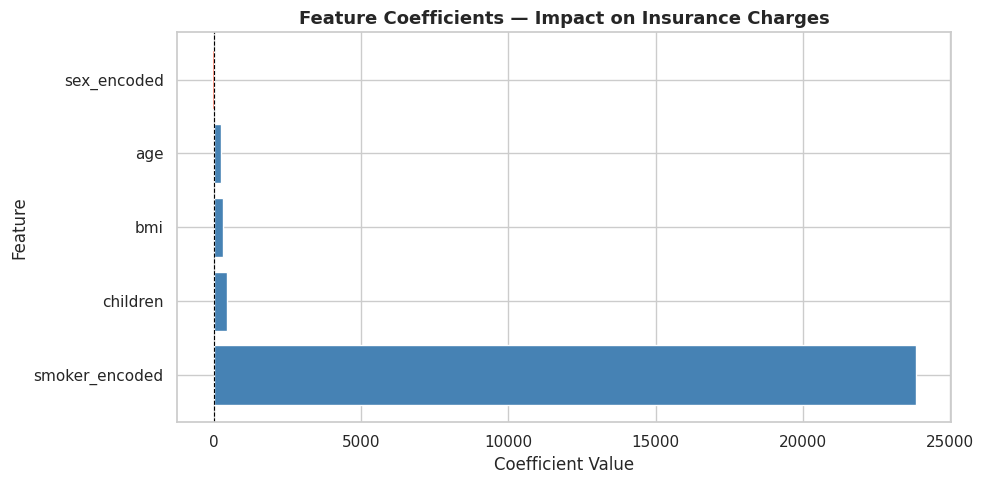


📌 Interpretation Guide:
   Positive coefficient → feature increases charges
   Negative coefficient → feature decreases charges
   Larger magnitude    → stronger influence


In [22]:
# ── 8.2  Visualize Coefficients ───────────────────────────────────
colors_bar = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]

plt.figure(figsize=(10, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_bar, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Feature Coefficients — Impact on Insurance Charges', fontsize=13, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\n📌 Interpretation Guide:")
print("   Positive coefficient → feature increases charges")
print("   Negative coefficient → feature decreases charges")
print("   Larger magnitude    → stronger influence")

In [23]:
# ── 8.3  Print the Full Regression Equation ───────────────────────
print("=" * 65)
print("  LEARNED REGRESSION EQUATION")
print("=" * 65)
print("\nCharges = ")
for feat, coef in zip(features_full, model.coef_):
    sign = '+' if coef >= 0 else '-'
    print(f"   {sign} ({abs(coef):.4f} × {feat})")
print(f"   + {model.intercept_:.4f}  ← intercept")
print()

  LEARNED REGRESSION EQUATION

Charges = 
   + (255.7349 × age)
   + (307.5137 × bmi)
   + (452.3477 × children)
   - (62.1795 × sex_encoded)
   + (23850.2056 × smoker_encoded)
   + -11586.6133  ← intercept



---
## 📏 Step 9 — Model Evaluation

We evaluate using three metrics:

| Metric | What it measures | Good value |
|--------|-----------------|------------|
| **R² Score** | % of variance in charges explained by the model | Closer to 1.0 is better |
| **MAE** | Average absolute difference between actual and predicted charges | Closer to 0 is better |
| **RMSE** | Like MAE but penalizes large errors more heavily | Closer to 0 is better |

In [24]:
# ── 9.1  Make Predictions ─────────────────────────────────────────
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

# ── 9.2  Compute Metrics ──────────────────────────────────────────
def evaluate_model(y_true, y_pred, label=''):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"  {'─'*40}")
    print(f"  {label}")
    print(f"  {'─'*40}")
    print(f"  R² Score : {r2:.4f}  ({r2*100:.2f}% variance explained)")
    print(f"  MAE      : ${mae:,.2f}")
    print(f"  RMSE     : ${rmse:,.2f}")
    return r2, mae, rmse

print("=" * 45)
print("  MODEL PERFORMANCE — FULL MODEL (Task A)")
print("=" * 45)
r2_tr, mae_tr, rmse_tr = evaluate_model(y_train, y_pred_train, 'TRAINING SET')
r2_te, mae_te, rmse_te = evaluate_model(y_test,  y_pred_test,  'TEST SET')

  MODEL PERFORMANCE — FULL MODEL (Task A)
  ────────────────────────────────────────
  TRAINING SET
  ────────────────────────────────────────
  R² Score : 0.7522  (75.22% variance explained)
  MAE      : $4,140.30
  RMSE     : $6,016.99
  ────────────────────────────────────────
  TEST SET
  ────────────────────────────────────────
  R² Score : 0.7388  (73.88% variance explained)
  MAE      : $4,169.89
  RMSE     : $6,331.94


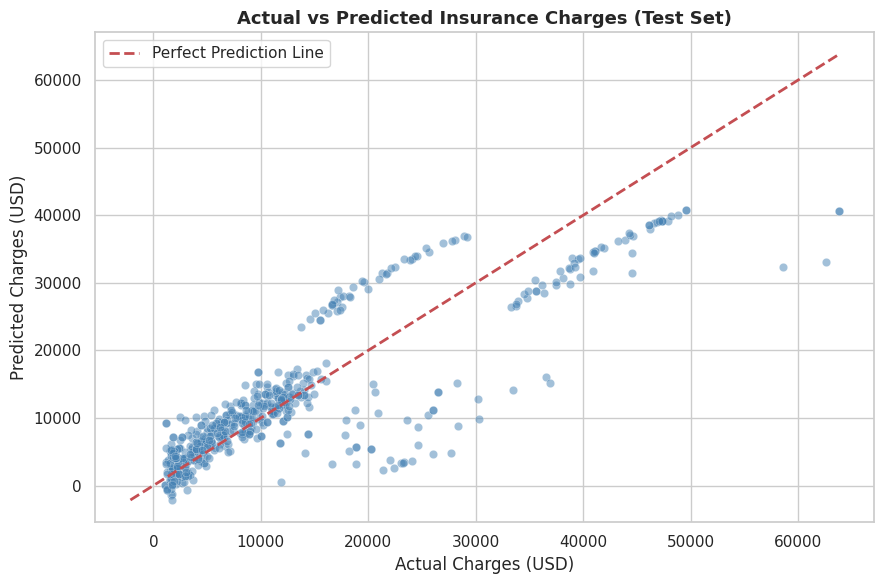

📌 Points close to the red dashed line = accurate predictions
   Points far from the line = larger prediction errors


In [25]:
# ── 9.3  Actual vs Predicted Plot ─────────────────────────────────
plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.3)
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction Line')
plt.xlabel('Actual Charges (USD)', fontsize=12)
plt.ylabel('Predicted Charges (USD)', fontsize=12)
plt.title('Actual vs Predicted Insurance Charges (Test Set)', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print("📌 Points close to the red dashed line = accurate predictions")
print("   Points far from the line = larger prediction errors")

---
## ✍️ Step 10 — Manual Verification Task

**Task:** Pick one sample from the test set, manually apply the regression formula using the learned coefficients, and verify it matches the model's prediction.

In [26]:
# ── 10.1  Pick One Sample ─────────────────────────────────────────
sample_index = 0                          # ✏️ Change this to try different samples
sample = X_test.iloc[[sample_index]]
actual_charge = y_test.iloc[sample_index]

print("=" * 55)
print("  SELECTED SAMPLE")
print("=" * 55)
for col in features_full:
    print(f"  {col:<25}: {sample[col].values[0]}")
print(f"\n  Actual Charges   : ${actual_charge:,.2f}")

  SELECTED SAMPLE
  age                      : 49
  bmi                      : 29.925
  children                 : 0
  sex_encoded              : 0
  smoker_encoded           : 0

  Actual Charges   : $8,988.16


In [27]:
# ── 10.2  Manual Formula Calculation ─────────────────────────────
print("=" * 55)
print("  MANUAL REGRESSION FORMULA VERIFICATION")
print("=" * 55)

manual_sum = 0
print("\n  Step-by-step calculation:")
print(f"  {'─'*50}")
for feat, coef in zip(features_full, model.coef_):
    val  = sample[feat].values[0]
    term = coef * val
    manual_sum += term
    print(f"  {coef:>12.4f}  ×  {feat:<28} ({val})  =  {term:>10.2f}")

manual_sum += model.intercept_
print(f"  {'─'*50}")
print(f"  {'Intercept (b)':<46}  =  {model.intercept_:>10.2f}")
print(f"  {'─'*50}")
print(f"  {'MANUAL PREDICTION':<46}  =  ${manual_sum:>9.2f}")

model_prediction = model.predict(sample)[0]
print(f"  {'MODEL PREDICTION':<46}  =  ${model_prediction:>9.2f}")
print(f"  {'ACTUAL CHARGES':<46}  =  ${actual_charge:>9.2f}")
print(f"  {'─'*50}")
print(f"  Difference (Manual vs Model) : ${abs(manual_sum - model_prediction):.4f}  ← should be ≈ 0")
print(f"  Prediction Error (vs Actual) : ${abs(model_prediction - actual_charge):,.2f}")

  MANUAL REGRESSION FORMULA VERIFICATION

  Step-by-step calculation:
  ──────────────────────────────────────────────────
      255.7349  ×  age                          (49)  =    12531.01
      307.5137  ×  bmi                          (29.925)  =     9202.35
      452.3477  ×  children                     (0)  =        0.00
      -62.1795  ×  sex_encoded                  (0)  =       -0.00
    23850.2056  ×  smoker_encoded               (0)  =        0.00
  ──────────────────────────────────────────────────
  Intercept (b)                                   =   -11586.61
  ──────────────────────────────────────────────────
  MANUAL PREDICTION                               =  $ 10146.74
  MODEL PREDICTION                                =  $ 10146.74
  ACTUAL CHARGES                                  =  $  8988.16
  ──────────────────────────────────────────────────
  Difference (Manual vs Model) : $0.0000  ← should be ≈ 0
  Prediction Error (vs Actual) : $1,158.58


---
## 📋 Step 11 — Actual vs Predicted Comparison Table

In [28]:
# ── 11.1  Comparison Table for First 15 Test Samples ─────────────
comparison_df = pd.DataFrame({
    'Actual Charges ($)'    : y_test.values[:15],
    'Predicted Charges ($)' : y_pred_test[:15],
    'Error ($)'             : y_test.values[:15] - y_pred_test[:15],
    'Abs Error ($)'         : np.abs(y_test.values[:15] - y_pred_test[:15])
}).round(2)

comparison_df.index = [f"Sample {i+1}" for i in range(15)]

print("=" * 65)
print("  ACTUAL vs PREDICTED — First 15 Test Samples")
print("=" * 65)
print(comparison_df.to_string())
print(f"\n  Average Absolute Error: ${comparison_df['Abs Error ($)'].mean():,.2f}")

  ACTUAL vs PREDICTED — First 15 Test Samples
           Actual Charges ($)  Predicted Charges ($)  Error ($)  Abs Error ($)
Sample 1              8988.16               10146.74   -1158.58        1158.58
Sample 2             28101.33               36266.05   -8164.72        8164.72
Sample 3             12032.33                9623.65    2408.68        2408.68
Sample 4              1682.60                6124.17   -4441.57        4441.57
Sample 5              3393.36                5811.33   -2417.97        2417.97
Sample 6             24106.91               33484.31   -9377.40        9377.40
Sample 7              4746.34                6087.90   -1341.55        1341.55
Sample 8             47269.85               39258.39    8011.46        8011.46
Sample 9              8556.91               11955.77   -3398.86        3398.86
Sample 10             2639.04                3135.43    -496.39         496.39
Sample 11            11552.90               13015.82   -1462.92        1462.92
Sample

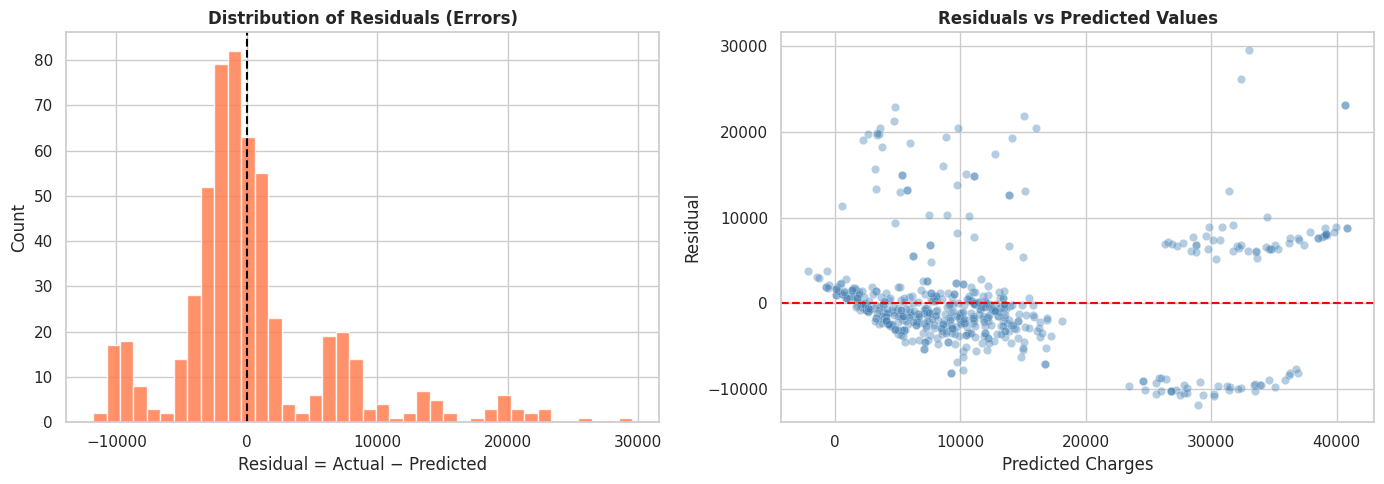

In [29]:
# ── 11.2  Residuals Plot ──────────────────────────────────────────
residuals = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual histogram
axes[0].hist(residuals, bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[0].set_title('Distribution of Residuals (Errors)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Residual = Actual − Predicted')
axes[0].set_ylabel('Count')

# Residuals vs Predicted
axes[1].scatter(y_pred_test, residuals, alpha=0.4, color='steelblue', edgecolors='white', linewidth=0.3)
axes[1].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_title('Residuals vs Predicted Values', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Charges')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

---
## 🧪 Step 12 — Practice Tasks / Experiments

Now you will train multiple models with different feature sets and compare their performance.

---
### 📌 Task A — Full Model (already done in Step 7)
Features: `age`, `bmi`, `children`, `sex_encoded`, `smoker_encoded`, all `region` dummies

In [30]:
# Task A results are already stored from Step 7-9
task_a = {'label': 'Task A — Full Model', 'r2': r2_te, 'mae': mae_te, 'rmse': rmse_te}
print(f"✅ Task A R²={r2_te:.4f}  MAE=${mae_te:,.2f}  RMSE=${rmse_te:,.2f}")

✅ Task A R²=0.7388  MAE=$4,169.89  RMSE=$6,331.94


---
### 📌 Task B — Numeric-Only Model
Features: `age`, `bmi`, `children` only

In [31]:
features_B = ['age', 'bmi', 'children']

X_B = df_encoded[features_B]
X_B_train, X_B_test, yB_train, yB_test = train_test_split(X_B, y, test_size=0.2, random_state=42)

model_B = LinearRegression()
model_B.fit(X_B_train, yB_train)
y_pred_B = model_B.predict(X_B_test)

r2_B  = r2_score(yB_test, y_pred_B)
mae_B = mean_absolute_error(yB_test, y_pred_B)
rmse_B = np.sqrt(mean_squared_error(yB_test, y_pred_B))

task_b = {'label': 'Task B — Numeric Only', 'r2': r2_B, 'mae': mae_B, 'rmse': rmse_B}

print("=" * 50)
print("  TASK B — Numeric-Only Model")
print("=" * 50)
print(f"  Features : {features_B}")
print(f"  R² Score : {r2_B:.4f}")
print(f"  MAE      : ${mae_B:,.2f}")
print(f"  RMSE     : ${rmse_B:,.2f}")

print(f"\n📌 Coefficients:")
for f, c in zip(features_B, model_B.coef_):
    print(f"   {f:<15}: {c:.4f}")
print(f"   Intercept     : {model_B.intercept_:.4f}")

  TASK B — Numeric-Only Model
  Features : ['age', 'bmi', 'children']
  R² Score : 0.1599
  MAE      : $8,908.89
  RMSE     : $11,355.33

📌 Coefficients:
   age            : 228.5627
   bmi            : 318.9610
   children       : 569.0519
   Intercept     : -6039.1223


---
### 📌 Task C — Add Encoded Categorical Variables
Features: `age`, `bmi`, `children` + `sex_encoded`, `smoker_encoded`, `region` dummies

In [33]:
# Select only columns that actually exist
features_C = [
    'age',
    'bmi',
    'children',
    'sex_encoded',
    'smoker_encoded'
]

# Add any region columns that exist
features_C += [col for col in df_encoded.columns if col.startswith('region_')]

print("Using features:", features_C)

X_C = df_encoded[features_C]

X_C_train, X_C_test, yC_train, yC_test = train_test_split(
    X_C, y, test_size=0.2, random_state=42
)

model_C = LinearRegression()
model_C.fit(X_C_train, yC_train)

y_pred_C = model_C.predict(X_C_test)

r2_C = r2_score(yC_test, y_pred_C)
mae_C = mean_absolute_error(yC_test, y_pred_C)
rmse_C = np.sqrt(mean_squared_error(yC_test, y_pred_C))

task_c = {
    'label': 'Task C — Full Encoded',
    'r2': r2_C,
    'mae': mae_C,
    'rmse': rmse_C
}

print("=" * 55)
print("  TASK C — Numeric + All Categorical Encoded")
print("=" * 55)
print(f"  R² Score : {r2_C:.4f}")
print(f"  MAE      : ${mae_C:,.2f}")
print(f"  RMSE     : ${rmse_C:,.2f}")

print("\n📌 Did adding categorical variables improve the model?")
print(f"   R² change: {r2_C - r2_B:+.4f} (vs Task B)")

Using features: ['age', 'bmi', 'children', 'sex_encoded', 'smoker_encoded']
  TASK C — Numeric + All Categorical Encoded
  R² Score : 0.7388
  MAE      : $4,169.89
  RMSE     : $6,331.94

📌 Did adding categorical variables improve the model?
   R² change: +0.5789 (vs Task B)


---
### 📌 Task D — Feature Comparison Experiment
Build 3 different models and compare performance

In [35]:
# Find existing region dummy columns
region_cols = [col for col in df_encoded.columns if col.startswith('region_')]

experiment_configs = [
    (
        'Model 1: age + bmi + children',
        ['age', 'bmi', 'children']
    ),
    (
        'Model 2: + smoker',
        ['age', 'bmi', 'children', 'smoker_encoded']
    ),
    (
        'Model 3: + sex + region',
        ['age', 'bmi', 'children', 'smoker_encoded', 'sex_encoded'] + region_cols
    )
]

experiment_results = []

print("=" * 65)
print("  TASK D — FEATURE COMPARISON EXPERIMENT")
print("=" * 65)

for label, feats in experiment_configs:

    # Keep only columns that actually exist
    feats = [f for f in feats if f in df_encoded.columns]

    Xd = df_encoded[feats]

    Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(
        Xd, y, test_size=0.2, random_state=42
    )

    md = LinearRegression()
    md.fit(Xd_tr, yd_tr)

    ypd = md.predict(Xd_te)

    r2d = r2_score(yd_te, ypd)
    maed = mean_absolute_error(yd_te, ypd)
    rmsed = np.sqrt(mean_squared_error(yd_te, ypd))

    experiment_results.append({
        'Model': label,
        'R²': r2d,
        'MAE': maed,
        'RMSE': rmsed
    })

    print(f"\n{label}")
    print(f"   Features: {feats}")
    print(f"   R²={r2d:.4f}  MAE=${maed:,.0f}  RMSE=${rmsed:,.0f}")

results_df = pd.DataFrame(experiment_results)

print("\n" + "=" * 65)
print("  COMPARISON TABLE")
print("=" * 65)

print(results_df.to_string(index=False))

  TASK D — FEATURE COMPARISON EXPERIMENT

Model 1: age + bmi + children
   Features: ['age', 'bmi', 'children']
   R²=0.1599  MAE=$8,909  RMSE=$11,355

Model 2: + smoker
   Features: ['age', 'bmi', 'children', 'smoker_encoded']
   R²=0.7388  MAE=$4,169  RMSE=$6,332

Model 3: + sex + region
   Features: ['age', 'bmi', 'children', 'smoker_encoded', 'sex_encoded']
   R²=0.7388  MAE=$4,170  RMSE=$6,332

  COMPARISON TABLE
                        Model   R²     MAE     RMSE
Model 1: age + bmi + children 0.16 8908.89 11355.33
            Model 2: + smoker 0.74 4168.99  6332.01
      Model 3: + sex + region 0.74 4169.89  6331.94


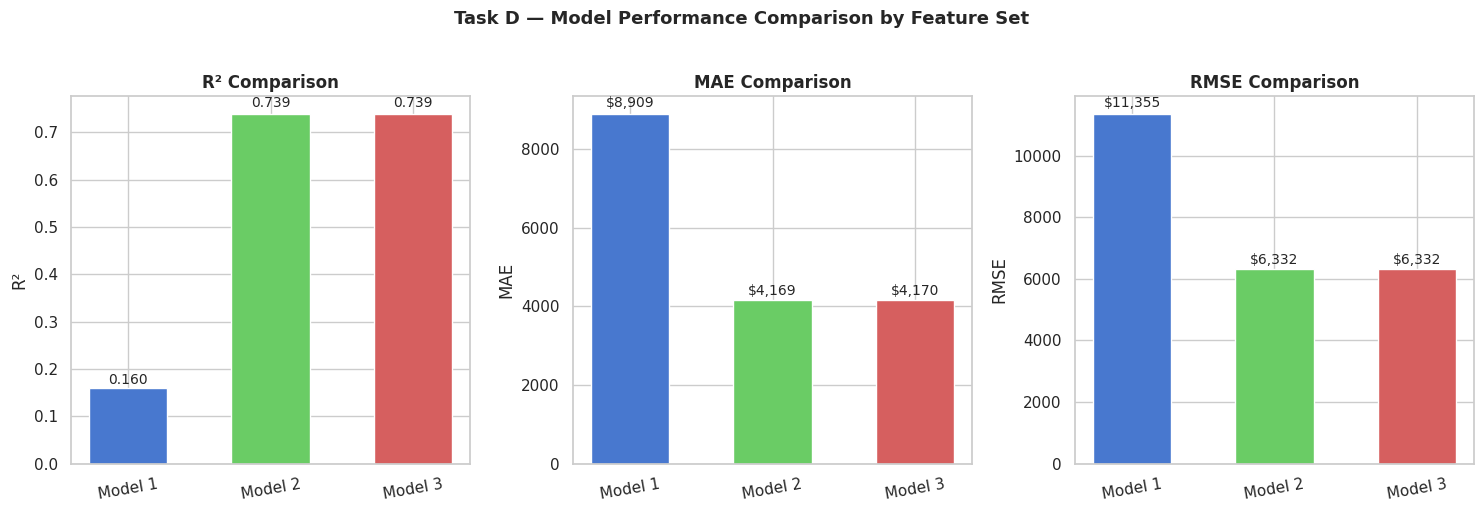

In [36]:
# ── Visualize Model Comparison ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
model_labels = [r['Model'].split(':')[0] for r in experiment_results]
colors_exp = ['#4878CF', '#6ACC65', '#D65F5F']

for ax, metric in zip(axes, ['R²', 'MAE', 'RMSE']):
    vals = [r[metric] for r in experiment_results]
    bars = ax.bar(model_labels, vals, color=colors_exp, edgecolor='white', width=0.55)
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=10)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.3f}' if metric == 'R²' else f'${val:,.0f}',
                ha='center', va='bottom', fontsize=10)

plt.suptitle('Task D — Model Performance Comparison by Feature Set',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
### 📌 Task E — Most Influential Feature Analysis

In [37]:
# ── Task E: Which feature matters most? ───────────────────────────
# Method 1: Coefficient magnitude from the full model

coef_abs = pd.DataFrame({
    'Feature'     : features_full,
    'Coefficient' : model.coef_,
    'Abs Value'   : np.abs(model.coef_)
}).sort_values('Abs Value', ascending=False)

print("=" * 55)
print("  TASK E — MOST INFLUENTIAL FEATURES")
print("  (Ranked by absolute coefficient value)")
print("=" * 55)
print(coef_abs.to_string(index=False))

# Method 2: Single-feature R² test
print("\n" + "=" * 55)
print("  SINGLE-FEATURE R² (one variable at a time)")
print("=" * 55)

single_feature_results = []
test_features = features_full
for feat in test_features:
    Xs = df_encoded[[feat]]
    Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(Xs, y, test_size=0.2, random_state=42)
    ms = LinearRegression().fit(Xs_tr, ys_tr)
    r2s = r2_score(ys_te, ms.predict(Xs_te))
    single_feature_results.append({'Feature': feat, 'R² (alone)': round(r2s, 4)})

sf_df = pd.DataFrame(single_feature_results).sort_values('R² (alone)', ascending=False)
print(sf_df.to_string(index=False))
print(f"\n📌 Most influential single feature: {sf_df.iloc[0]['Feature']} (R²={sf_df.iloc[0]['R² (alone)']:.4f})")

  TASK E — MOST INFLUENTIAL FEATURES
  (Ranked by absolute coefficient value)
       Feature  Coefficient  Abs Value
smoker_encoded     23850.21   23850.21
      children       452.35     452.35
           bmi       307.51     307.51
           age       255.73     255.73
   sex_encoded       -62.18      62.18

  SINGLE-FEATURE R² (one variable at a time)
       Feature  R² (alone)
smoker_encoded        0.60
           age        0.12
           bmi        0.05
      children        0.00
   sex_encoded       -0.00

📌 Most influential single feature: smoker_encoded (R²=0.5991)


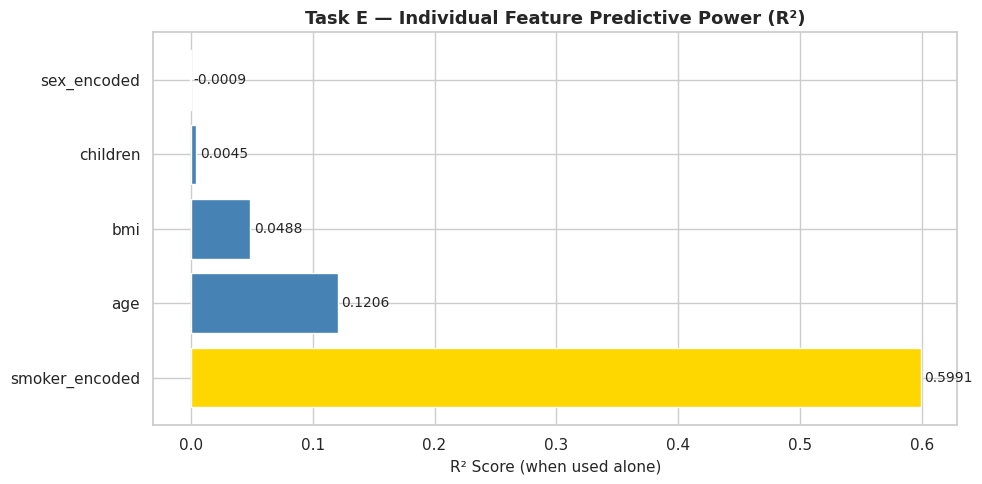

In [38]:
# ── Visualize Single-Feature R² ───────────────────────────────────
plt.figure(figsize=(10, 5))
sf_colors = ['gold' if f == sf_df.iloc[0]['Feature'] else 'steelblue' for f in sf_df['Feature']]
bars = plt.barh(sf_df['Feature'], sf_df['R² (alone)'], color=sf_colors, edgecolor='white')
plt.xlabel('R² Score (when used alone)', fontsize=11)
plt.title('Task E — Individual Feature Predictive Power (R²)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, sf_df['R² (alone)']):
    plt.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## 🚀 Step 14 — Extra Practice Ideas

In [39]:
# ── Extra 1: Smoker-Only Model ────────────────────────────────────
# Does smoker alone have strong predictive power?
X_smoker = df_encoded[['smoker_encoded']]
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(X_smoker, y, test_size=0.2, random_state=42)
m_smoker = LinearRegression().fit(Xs_tr, ys_tr)
r2_smoker = r2_score(ys_te, m_smoker.predict(Xs_te))
print(f"📌 Smoker-Only Model R²: {r2_smoker:.4f}")
print(f"   → Smoker alone explains {r2_smoker*100:.1f}% of charge variance")

📌 Smoker-Only Model R²: 0.5991
   → Smoker alone explains 59.9% of charge variance


In [40]:
# ── Extra 2: Feature Scaling (Optional) ──────────────────────────
# Does StandardScaler change R²? (It shouldn't for Linear Regression)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaled = LinearRegression().fit(X_scaled, y_train)
r2_scaled = r2_score(y_test, model_scaled.predict(X_test_scaled))

print("=" * 50)
print("  FEATURE SCALING EXPERIMENT")
print("=" * 50)
print(f"  Without Scaling R² : {r2_te:.4f}")
print(f"  With Scaling R²    : {r2_scaled:.4f}")
print(f"\n📌 Conclusion: Scaling {'DOES' if abs(r2_te - r2_scaled) > 0.001 else 'does NOT'} change R² for Linear Regression")
print("   (Scaling mainly affects coefficient magnitudes, not prediction accuracy)")

  FEATURE SCALING EXPERIMENT
  Without Scaling R² : 0.7388
  With Scaling R²    : 0.7388

📌 Conclusion: Scaling does NOT change R² for Linear Regression
   (Scaling mainly affects coefficient magnitudes, not prediction accuracy)


  NUMERIC FEATURE CORRELATION
          age   bmi  children  charges
age      1.00  0.11      0.04     0.30
bmi      0.11  1.00     -0.00     0.20
children 0.04 -0.00      1.00     0.07
charges  0.30  0.20      0.07     1.00


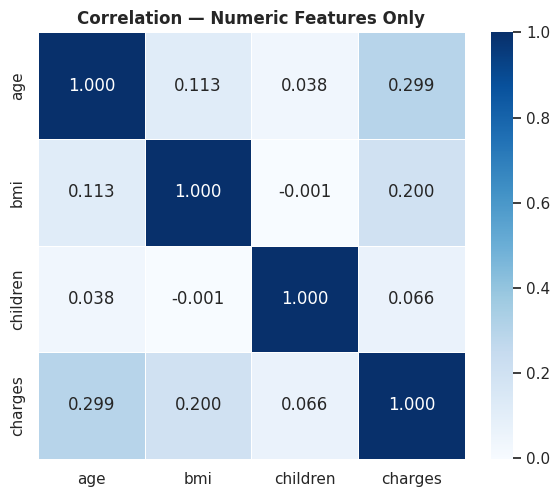

In [41]:
# ── Extra 3: Correlation Among Numeric Features ───────────────────
print("=" * 45)
print("  NUMERIC FEATURE CORRELATION")
print("=" * 45)
numeric_only = df[['age', 'bmi', 'children', 'charges']]
print(numeric_only.corr().round(3))

plt.figure(figsize=(6, 5))
sns.heatmap(numeric_only.corr(), annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.5, square=True)
plt.title('Correlation — Numeric Features Only', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [43]:
# ── Extra 4: Remove One Feature and Retrain ───────────────────────
# ✏️ Change 'bmi' to any feature you want to remove
feature_to_remove = 'bmi'

features_reduced = [f for f in features_full if f != feature_to_remove]
X_red = df_encoded[features_reduced]
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_red, y, test_size=0.2, random_state=42)
m_red = LinearRegression().fit(Xr_tr, yr_tr)
r2_red = r2_score(yr_te, m_red.predict(Xr_te))

print("=" * 55)
print(f"  REMOVE '{feature_to_remove}' EXPERIMENT")
print("=" * 55)
print(f"  Full Model R²    : {r2_te:.4f}")
print(f"  Reduced Model R² : {r2_red:.4f}")
print(f"  R² Change        : {r2_red - r2_te:+.4f}")
impact = 'NEGATIVE' if r2_red < r2_te else 'MINIMAL/POSITIVE'
print(f"\n📌 Removing '{feature_to_remove}' had a {impact} impact on model performance.")

  REMOVE 'bmi' EXPERIMENT
  Full Model R²    : 0.7388
  Reduced Model R² : 0.7119
  R² Change        : -0.0269

📌 Removing 'bmi' had a NEGATIVE impact on model performance.


---
## 📝 Step 15 — Final Summary & Submission Checklist

Use the cell below to write your final summary report.

### ✅ Assignment Completion Checklist

Before submitting, verify you have completed:

- [ ] **Title** — Assignment title stated
- [ ] **Objective** — Learning goals described
- [ ] **Dataset Description** — Shape, columns, types explained
- [ ] **Features and Target** — X and y defined
- [ ] **Data Preprocessing** — Null check, encoding applied
- [ ] **Feature Encoding** — Categorical variables encoded correctly
- [ ] **Train-Test Split** — 80/20 split performed
- [ ] **Model Training** — LinearRegression model fitted
- [ ] **Regression Equation** — Written out with actual coefficients
- [ ] **Manual Verification** — One sample verified manually
- [ ] **Actual vs Predicted** — Table and plot produced
- [ ] **Task A through E** — All practice experiments completed
- [ ] **Discussion Q1–Q8** — All questions answered
- [ ] **Conclusion** — Written below

---

### 📝 Conclusion

> ✏️ *Write your conclusion here:*
>
> In this assignment, I applied Multivariate Linear Regression to predict medical insurance charges. The key findings were:
>
> 1. ...
> 2. ...
> 3. ...
>
> The best performing model was ... with R²=... The most influential feature was ...
>
> Possible improvements for the future include: ...

In [44]:
# ── Final Summary Table ───────────────────────────────────────────
all_results = [
    task_a,
    task_b,
    task_c,
    {'label': 'Task D — Model 1 (age+bmi+children)',   'r2': experiment_results[0]['R²'], 'mae': experiment_results[0]['MAE'], 'rmse': experiment_results[0]['RMSE']},
    {'label': 'Task D — Model 2 (+smoker)',             'r2': experiment_results[1]['R²'], 'mae': experiment_results[1]['MAE'], 'rmse': experiment_results[1]['RMSE']},
    {'label': 'Task D — Model 3 (+sex+region)',         'r2': experiment_results[2]['R²'], 'mae': experiment_results[2]['MAE'], 'rmse': experiment_results[2]['RMSE']},
]

summary_df = pd.DataFrame(all_results)
summary_df.columns = ['Model', 'R² Score', 'MAE ($)', 'RMSE ($)']
summary_df = summary_df.round({'R² Score': 4, 'MAE ($)': 0, 'RMSE ($)': 0})

print("=" * 75)
print("  🏆  FINAL RESULTS SUMMARY — ALL EXPERIMENTS")
print("=" * 75)
print(summary_df.to_string(index=False))
best = summary_df.loc[summary_df['R² Score'].idxmax()]
print(f"\n🥇 Best Model : {best['Model']}")
print(f"   R² Score   : {best['R² Score']}")
print(f"   MAE        : ${best['MAE ($)']:,.0f}")
print(f"   RMSE       : ${best['RMSE ($)']:,.0f}")

  🏆  FINAL RESULTS SUMMARY — ALL EXPERIMENTS
                              Model  R² Score  MAE ($)  RMSE ($)
                Task A — Full Model      0.74  4170.00   6332.00
              Task B — Numeric Only      0.16  8909.00  11355.00
              Task C — Full Encoded      0.74  4170.00   6332.00
Task D — Model 1 (age+bmi+children)      0.16  8909.00  11355.00
         Task D — Model 2 (+smoker)      0.74  4169.00   6332.00
     Task D — Model 3 (+sex+region)      0.74  4170.00   6332.00

🥇 Best Model : Task A — Full Model
   R² Score   : 0.7388
   MAE        : $4,170
   RMSE       : $6,332
